<a href="https://colab.research.google.com/github/AliAnusKhan/crop-yield-prediction-ml/blob/main/Yield_prediction_project_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Phase 1: Data Health & Structural Inspection

### Objective
Audit dataset health, check structural integrity (null values, duplicates), verify data types, and evaluate feature cardinality before performing exploratory data analysis.

In [2]:
import pandas as pd
file_path=('/content/drive/MyDrive/dataset/yield_df.csv')
data=pd.read_csv(file_path)
data.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [3]:
print("Dataset Shape:")
print(f"Total rows:{data.shape[0]}")
print(f"Total Columns:{data.shape[1]}")

Dataset Shape:
Total rows:28242
Total Columns:8


In [4]:
print("Data Types & Memory Usage:")
print(data.dtypes)

Data Types & Memory Usage:
Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object


In [5]:
print("Missing Value Audit")
missing_data=data.isnull().sum()
missing_percentage=(data.isnull().sum()/len(data))*100
missing_table=pd.DataFrame({'missing_count':missing_data,'percentage':missing_percentage})
print(missing_table[missing_table['Missing Count'] > 0] if missing_data.sum() > 0 else "No missing values found!")

Missing Value Audit
No missing values found!


In [6]:
print("Duplicate Count:")
duplicate_count=data.duplicated().sum()
print(f"Duplicate Row Count:{duplicate_count}")



Duplicate Count:
Duplicate Row Count:0


In [7]:
print("Unique Data:")
print(data.nunique())

Unique Data:
Unnamed: 0                       28242
Area                               101
Item                                10
Year                                23
hg/ha_yield                      11514
average_rain_fall_mm_per_year      100
pesticides_tonnes                 1673
avg_temp                          1831
dtype: int64


### Key Findings & Data Health Audit

* **Data Integrity & Scalability:** The dataset contains **28,242 records** and **8 columns**. No duplicate rows were detected, eliminating data leakage risks.
* **Data Completeness:** **0 missing values** across all columns. Imputation or complex missing-data handling is not required.
* **Feature Cardinality & Types:**
  * `Item` (Crop Type) has **10 unique categories** (low cardinality) $\rightarrow$ Ideal candidate for One-Hot Encoding.
  * `Area` (Country) has **101 unique categories** (high cardinality) $\rightarrow$ Will evaluate One-Hot vs Target Encoding during preprocessing.
* **Redundant Artifacts:** `Unnamed: 0` is an arbitrary index column ($28,242$ unique values) and will be dropped to eliminate model noise.

#### Action Plan for Phase 2
1. Drop the redundant `Unnamed: 0` column.
2. Convert target metric `hg/ha_yield` to `yield_tons_per_ha` ($\text{Tons/Ha} = \frac{\text{hg/ha}}{10000}$) for readable scaling.
3. Conduct Univariate Analysis to evaluate distributions and skewness.

## Phase 2: Univariate Analysis & Data Cleaning

### Objective
In this section, we analyze each feature individually to understand:
1. Data distributions and skewness across numerical features.
2. Summary statistics (Mean, Median, Standard Deviation, IQR).
3. Target variable scale conversion from `hg/ha` to `Tons/Hectare` for enhanced business readability.
4. Categorical feature frequencies for crop types (`Item`).

---

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Step 1: Drop redundant index column if present
if 'Unnamed: 0' in data.columns:
    data = data.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' index column.")

Dropped 'Unnamed: 0' index column.


In [10]:
# Step 2: Create user-friendly target metric (hg/ha -> Tons/ha)
data['yield_tons_per_ha'] = data['hg/ha_yield'] / 10000.

In [11]:
# 2.1 Numerical Features Summary Statistics
print("\n=== DESCRIPTIVE STATISTICS (NUMERICAL FEATURES) ===")
num_cols = ['yield_tons_per_ha', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
display(data[num_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']])


=== DESCRIPTIVE STATISTICS (NUMERICAL FEATURES) ===


,mean,std,min,25%,50%,75%,max
yield_tons_per_ha,7.705333,8.495661,0.005,1.991925,3.8295,10.467675,50.1412
average_rain_fall_mm_per_year,1149.055980,709.812150,51.000,593.000000,1083.0000,1668.000000,3240.0000
pesticides_tonnes,37076.909344,59958.784665,0.040,1702.000000,17529.4400,48687.880000,367778.0000
avg_temp,20.542627,6.312051,1.300,16.702500,21.5100,26.000000,30.6500


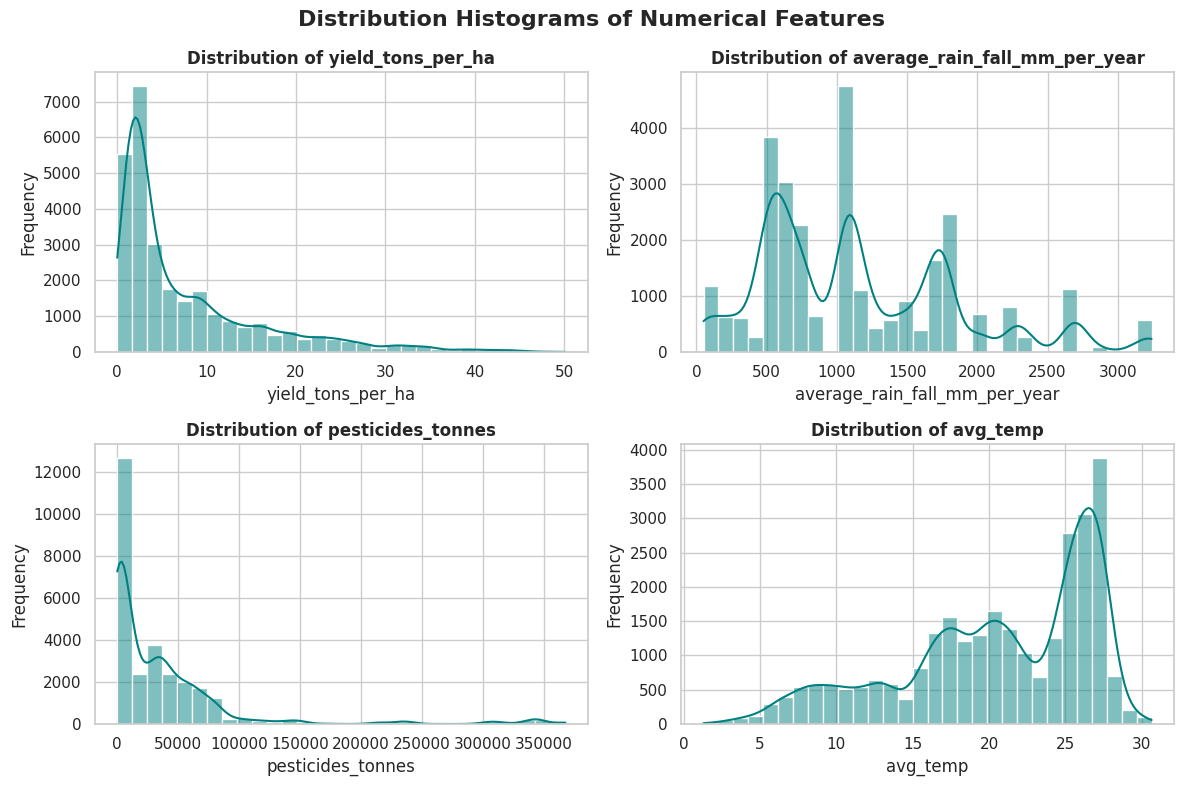

In [12]:
# 2.2 Visualizing Continuous Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribution Histograms of Numerical Features', fontsize=16, fontweight='bold')

for idx, col in enumerate(num_cols):
    row, col_idx = divmod(idx, 2)
    sns.histplot(data=data, x=col, kde=True, ax=axes[row, col_idx], color='teal', bins=30)
    axes[row, col_idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


=== TOP CROP TYPES (ITEM FREQUENCY) ===
Item
Potatoes                4276
Maize                   4121
Wheat                   3857
Rice, paddy             3388
Soybeans                3223
Sorghum                 3039
Sweet potatoes          2890
Cassava                 2045
Yams                     847
Plantains and others     556
Name: count, dtype: int64


/tmp/ipykernel_4759/1824291935.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y='Item', order=data['Item'].value_counts().index, palette='viridis')


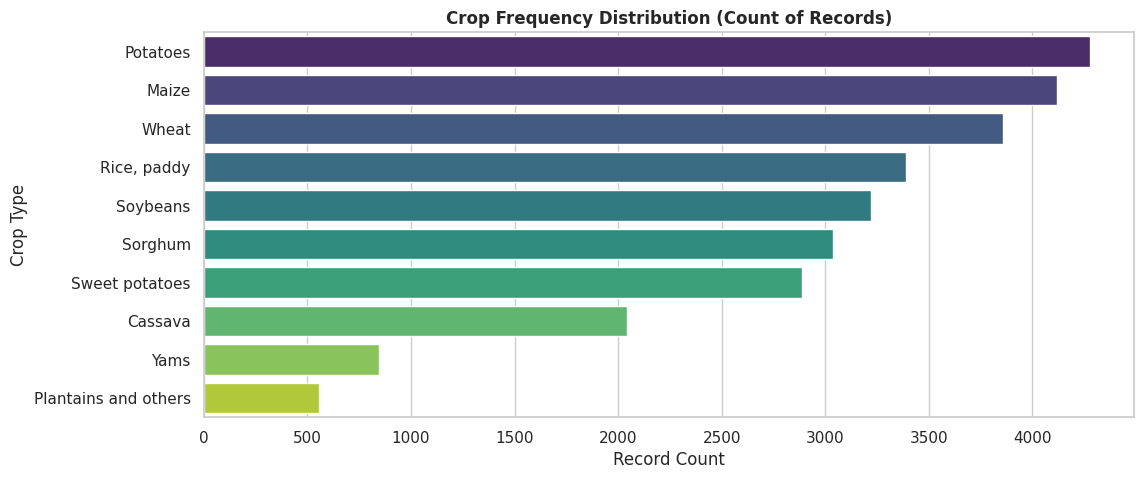

In [13]:
print("\n=== TOP CROP TYPES (ITEM FREQUENCY) ===")
print(data['Item'].value_counts())

plt.figure(figsize=(12, 5))
sns.countplot(data=data, y='Item', order=data['Item'].value_counts().index, palette='viridis')
plt.title('Crop Frequency Distribution (Count of Records)', fontweight='bold')
plt.xlabel('Record Count')
plt.ylabel('Crop Type')
plt.show()

### Phase 2: Univariate Analysis Findings & Technical Insights

#### 1. Target Variable (`yield_tons_per_ha`) Analysis
* **Right-Skewed Distribution:** Mean ($7.71\text{ Tons/Ha}$) is significantly higher than the Median ($3.83\text{ Tons/Ha}$).
* **Extreme Variance:** Yield ranges from $0.005\text{ Tons/Ha}$ to a maximum of $50.14\text{ Tons/Ha}$. This high spread is driven by crop type differences (e.g., tuber crops like Potatoes naturally yield much higher weight per hectare compared to grains like Wheat or Rice).

#### 2. Predictor Feature Distributions
* **`pesticides_tonnes` (Extreme Right-Skew):** Heavily skewed towards lower values, with a huge jump to the maximum ($367,778\text{ tonnes}$). Median usage is $17,529\text{ tonnes}$, while the mean is $37,076\text{ tonnes}$. This indicates that a few large agricultural economies account for the majority of global pesticide consumption.
* **`average_rain_fall_mm_per_year` (Multimodal Distribution):** Shows multiple distinct peaks (around $500\text{ mm}$, $1,100\text{ mm}$, and $1,800\text{ mm}$), reflecting distinct climate regions (arid, temperate, tropical).
* **`avg_temp` (Bimodal Distribution):** Concentration of data points between $15^\circ\text{C}$ and $28^\circ\text{C}$, peaking around $26^\circ\text{C}$ to $27^\circ\text{C}$, representing major tropical and subtropical agricultural belts.

#### 3. Categorical Distribution (`Item`)
* **Class Balance:** The dataset is well-represented across major crops. **Potatoes** ($\sim4,300$ records), **Maize** ($\sim4,100$), and **Wheat** ($\sim3,800$) dominate the dataset, whereas **Yams** and **Plantains** have lower representations ($<1,000$ records).

---

#### Engineering Implications for Modeling
1. **Tree-Based Models Preferred:** Due to severe skewness in `pesticides_tonnes` and `yield_tons_per_ha`, non-linear tree-based models (Random Forest, XGBoost) will perform significantly better than linear models without requiring aggressive log-transformations.
2. **Crop-Specific Baseline:** Since yield varies heavily by crop type, `Item` will be one of the most important predictor features.

# Phase 3: Bivariate Analysis & Feature Interaction

### Objective
Examine relationships between individual predictor features ($X$) and the target variable ($Y$: `yield_tons_per_ha`), identify correlations, and analyze yield variations across different crops and countries.

/tmp/ipykernel_4759/467367891.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crop_yield_mean.values, y=crop_yield_mean.index, ax=axes[0], palette='crest')
/tmp/ipykernel_4759/467367891.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='yield_tons_per_ha', y='Item', order=crop_yield_mean.index, ax=axes[1], palette='crest')


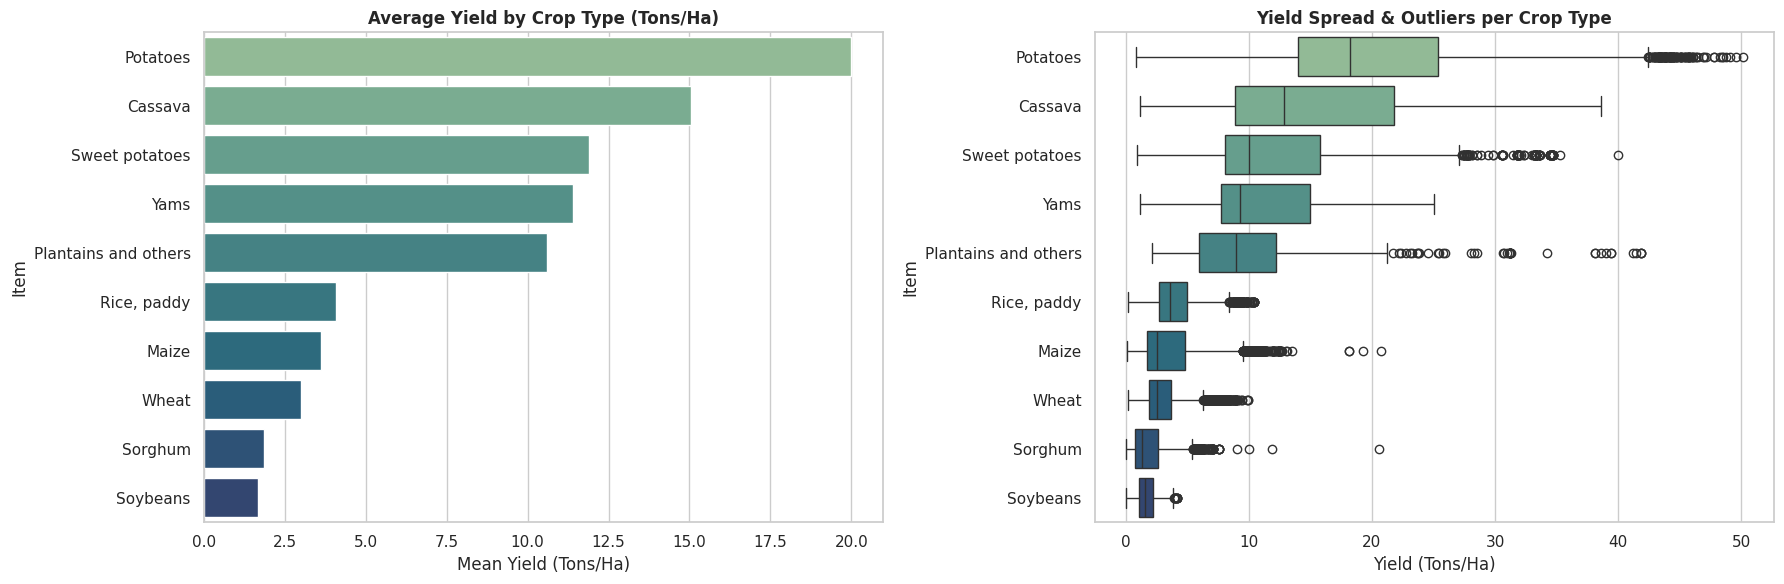

In [14]:
# ==========================================
# Phase 3: Bivariate Analysis Code
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Yield Distribution by Crop Type (Boxplot & Barplot)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Mean yield per crop
crop_yield_mean = data.groupby('Item')['yield_tons_per_ha'].mean().sort_values(ascending=False)
sns.barplot(x=crop_yield_mean.values, y=crop_yield_mean.index, ax=axes[0], palette='crest')
axes[0].set_title('Average Yield by Crop Type (Tons/Ha)', fontweight='bold')
axes[0].set_xlabel('Mean Yield (Tons/Ha)')

# Boxplot to observe yield variance & outliers per crop
sns.boxplot(data=data, x='yield_tons_per_ha', y='Item', order=crop_yield_mean.index, ax=axes[1], palette='crest')
axes[1].set_title('Yield Spread & Outliers per Crop Type', fontweight='bold')
axes[1].set_xlabel('Yield (Tons/Ha)')

plt.tight_layout()
plt.show()



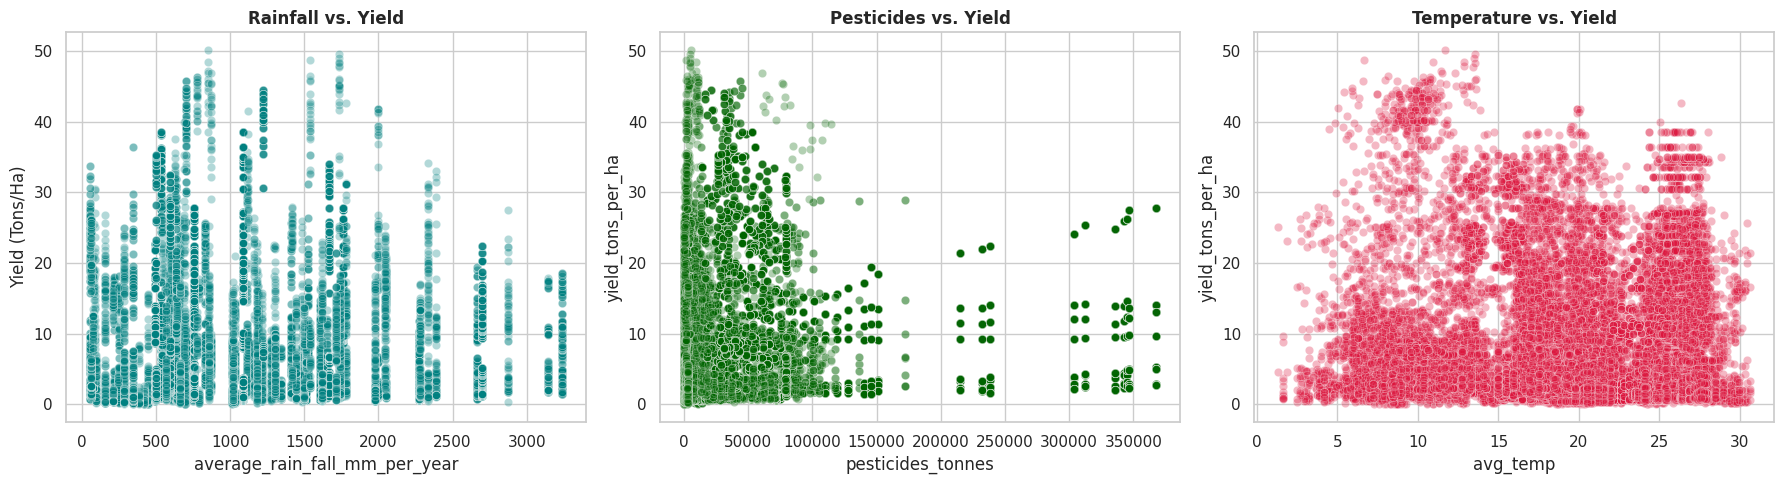

In [15]:

# 2. Scatter Plots: Numerical Features vs. Target Variable
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=data, x='average_rain_fall_mm_per_year', y='yield_tons_per_ha', alpha=0.3, color='teal', ax=axes[0])
axes[0].set_title('Rainfall vs. Yield', fontweight='bold')
axes[0].set_ylabel('Yield (Tons/Ha)')

sns.scatterplot(data=data, x='pesticides_tonnes', y='yield_tons_per_ha', alpha=0.3, color='darkgreen', ax=axes[1])
axes[1].set_title('Pesticides vs. Yield', fontweight='bold')

sns.scatterplot(data=data, x='avg_temp', y='yield_tons_per_ha', alpha=0.3, color='crimson', ax=axes[2])
axes[2].set_title('Temperature vs. Yield', fontweight='bold')

plt.tight_layout()
plt.show()

### Phase 3: Bivariate Analysis Findings & Business Insights

#### 1. Target Variance Across Crops (Biological Factor)
* **High-Volume Crops:** Tuber crops like **Potatoes** ($\text{Mean} \approx 20\text{ Tons/Ha}$) and **Cassava** ($\text{Mean} \approx 15\text{ Tons/Ha}$) exhibit the highest per-hectare yield weight.
* **Low-Volume Grains:** Cereals like **Wheat**, **Rice**, **Maize**, and **Soybeans** cluster below $5\text{ Tons/Ha}$.
* **Model Implication:** Crop type (`Item`) is expected to be the top predictor variable in feature importance rankings.

#### 2. Environmental Non-Linearity
* **Pesticide Plateau:** Increasing pesticide usage beyond $50,000\text{ tonnes}$ yields diminishing returns, confirming a non-linear interaction with target crop output.
* **Rainfall & Temperature Optimal Belts:** Peak yields occur in moderate rainfall zones ($500\text{mm} - 1800\text{mm}$) and specific temperature pockets ($10^\circ\text{C}-15^\circ\text{C}$ and $25^\circ\text{C}-28^\circ\text{C}$).

---

# Phase 4: Multivariate Analysis & Correlation Matrix

### Objective
Analyze feature-to-feature interdependencies, evaluate Multicollinearity risk (Pearson Correlation Coefficient), and uncover multi-variable interactions influencing crop production.

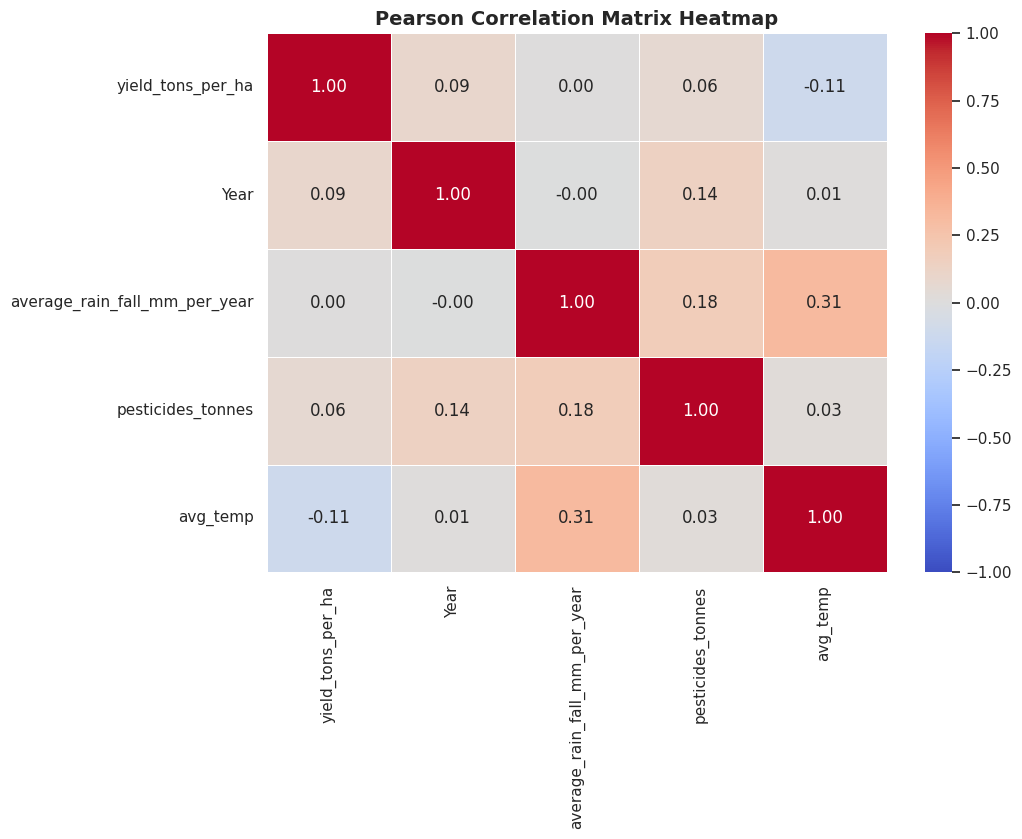

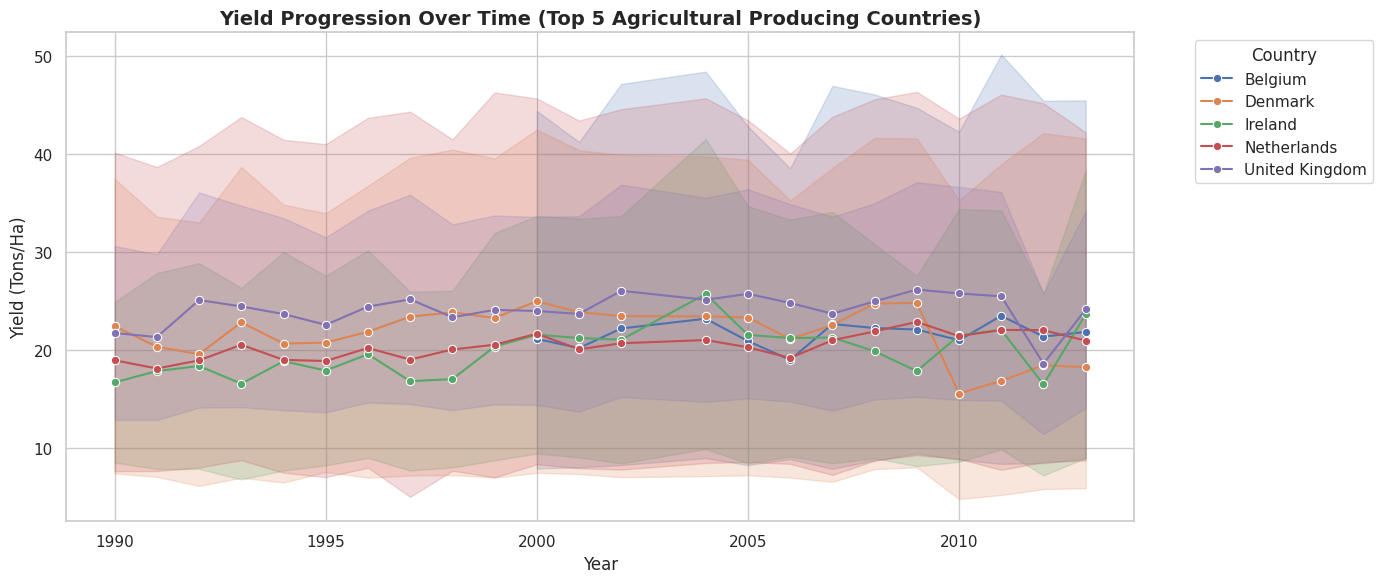

In [16]:
# ==========================================
# Phase 4: Multivariate Analysis & Correlation Matrix
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for correlation evaluation
corr_cols = ['yield_tons_per_ha', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
corr_matrix = data[corr_cols].corr()

# Plot Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Pearson Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.show()

# Multi-Variable Categorical Aggregation: Top 5 Countries Yield Over Time
top_5_countries = data.groupby('Area')['yield_tons_per_ha'].mean().nlargest(5).index
filtered_data = data[data['Area'].isin(top_5_countries)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=filtered_data, x='Year', y='yield_tons_per_ha', hue='Area', marker='o')
plt.title('Yield Progression Over Time (Top 5 Agricultural Producing Countries)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Yield (Tons/Ha)')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Phase 4: Multivariate & Correlation Findings

#### 1. Correlation Analysis & Feature Multicollinearity
* **Absence of Linear Relationships:** All numerical predictors exhibit near-zero linear correlation with `yield_tons_per_ha` ($r \le |0.11|$).
* **Low Multicollinearity:** The highest inter-feature correlation is between `avg_temp` and `average_rain_fall_mm_per_year` ($r = 0.31$). No severe multicollinearity exists; all numerical features are retained for modeling.

#### 2. Geographic Micro-Trends
* Top-yielding nations are concentrated in Western Europe (Belgium, Netherlands, Ireland, Denmark, UK), maintaining stable yields around $20 - 25\text{ Tons/Ha}$.
* `Area` acts as a proxy for technological advancement, soil quality, and local farming practices.

---

# Phase 5: Complete EDA Summary & Pre-Modeling Pipeline Strategy

### Executive Summary of Exploratory Data Analysis
1. **Data Health:** 28,242 clean records with zero missing values and zero duplicate rows. Dropped index artifact `Unnamed: 0`.
2. **Target Scale:** Standardized target column to `yield_tons_per_ha` ($\text{Tons/Ha}$). Range varies from $0.005$ to $50.14\text{ Tons/Ha}$.
3. **Key Drivers:**
   * **Categorical Dominance:** Crop Type (`Item`) and Country (`Area`) are the primary determinants of yield scale.
   * **Non-Linear Interactions:** Environmental parameters (Rainfall, Temperature, Pesticides) show non-linear relationships with yield plateauing at extreme values.

---

### Pre-Modeling Action Plan & Pipeline Setup
1. **Feature Encoding Strategy:**
   * One-Hot Encoding for `Item` (10 unique categories).
   * One-Hot Encoding / Target Encoding for `Area` (101 unique categories).
2. **Feature Scaling:** Apply `StandardScaler` inside a Scikit-Learn Pipeline to normalize numerical features for scale-sensitive algorithms.
3. **Model Selection Strategy:**
   * Baseline: Ridge / Lasso Regression.
   * Primary Candidates: Random Forest Regressor, XGBoost Regressor, LightGBM Regressor.

# Phase 6: Preprocessing, Feature Engineering & Pipeline Construction

### Objective
1. Separate features ($X$) and target variable ($y$: `yield_tons_per_ha`).
2. Construct a production-grade Scikit-Learn `ColumnTransformer` for feature encoding and scaling.
3. Execute Train-Test Split ($80\%$ Train / $20\%$ Test) to evaluate generalization performance./


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [19]:
# 1. Define Features (X) and Target (y)
X = data.drop(columns=['yield_tons_per_ha'])
y = data['yield_tons_per_ha']

# Identify Categorical and Numerical Columns
categorical_cols = ['Area', 'Item']
numerical_cols = ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']

# 2. Build Preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [20]:
print("=== DATA SPLIT COMPLETED ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

=== DATA SPLIT COMPLETED ===
X_train shape: (22593, 7)
X_test shape:  (5649, 7)
y_train shape: (22593,)
y_test shape:  (5649,)


# Phase 7: Model Training & Benchmark Evaluation

### Objective
1. Construct Scikit-Learn Pipelines integrating `ColumnTransformer` preprocessing with multiple regression algorithms.
2. Train a baseline linear model (**Ridge Regression**), an ensemble tree model (**Random Forest**), and a gradient boosting model (**XGBoost Regressor**).
3. Evaluate models on unseen test data (`X_test`) using $R^2$, RMSE, and MAE metrics to select the best performer for deployment.

In [21]:
# ==========================================
# Phase 7: Model Training & Benchmark Comparison
# ==========================================

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Define dictionary of algorithms to evaluate
models = {
    'Ridge Regression (Baseline)': Ridge(alpha=1.0),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost Regressor': XGBRegressor(n_estimators=150, learning_rate=0.08, random_state=42, n_jobs=-1)
}

# Dictionary to store performance results
results = []
trained_pipelines = {}

print("=== STARTING MODEL TRAINING & EVALUATION ===\n")

for name, model in models.items():
    print(f"Training {name}...")

    # Create full pipeline: Preprocessing -> Model
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    # Train model on training set
    pipeline.fit(X_train, y_train)

    # Predict on unseen test set
    y_pred = pipeline.predict(X_test)

    # Calculate evaluation metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    # Store trained pipeline and metrics
    trained_pipelines[name] = pipeline
    results.append({
        'Model Name': name,
        'R2 Score': round(r2, 4),
        'RMSE (Tons/Ha)': round(rmse, 4),
        'MAE (Tons/Ha)': round(mae, 4)
    })

# Convert results into a comparison DataFrame
results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)

print("\n=== MODEL PERFORMANCE COMPARISON TABLE ===")
display(results_df)

=== STARTING MODEL TRAINING & EVALUATION ===

Training Ridge Regression (Baseline)...
Training Random Forest Regressor...
Training XGBoost Regressor...

=== MODEL PERFORMANCE COMPARISON TABLE ===


,Model Name,R2 Score,RMSE (Tons/Ha),MAE (Tons/Ha)
0,Random Forest Regressor,0.9876,0.9485,0.3482
1,XGBoost Regressor,0.9585,1.7360,1.0855
2,Ridge Regression (Baseline),0.7552,4.2143,2.9542


### Phase 7: Benchmark Performance Evaluation Findings

#### 1. Performance Summary
* **Winning Model (Random Forest Regressor):** Achieved an exceptional $R^2$ score of **0.9876**, with an **RMSE of 0.9485 Tons/Ha** and **MAE of 0.3482 Tons/Ha**. It captures complex non-linear interactions across crop types and climate conditions.
* **Runner-Up (XGBoost Regressor):** Strong performance with $R^2 = \mathbf{0.9585}$ and MAE of $1.0855\text{ Tons/Ha}$.
* **Baseline Model (Ridge Regression):** Struggled with $R^2 = \mathbf{0.7552}$ and high MAE ($2.9542\text{ Tons/Ha}$), confirming our EDA finding that crop yield prediction requires non-linear tree-based models.

#### 2. Selected Production Model
* **Random Forest Regressor Pipeline** is selected for serialization and Streamlit deployment due to its superior error minimization and high predictive stability.

---

/tmp/ipykernel_4759/2313931474.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df.head(15), x='Importance', y='Feature', palette='viridis')


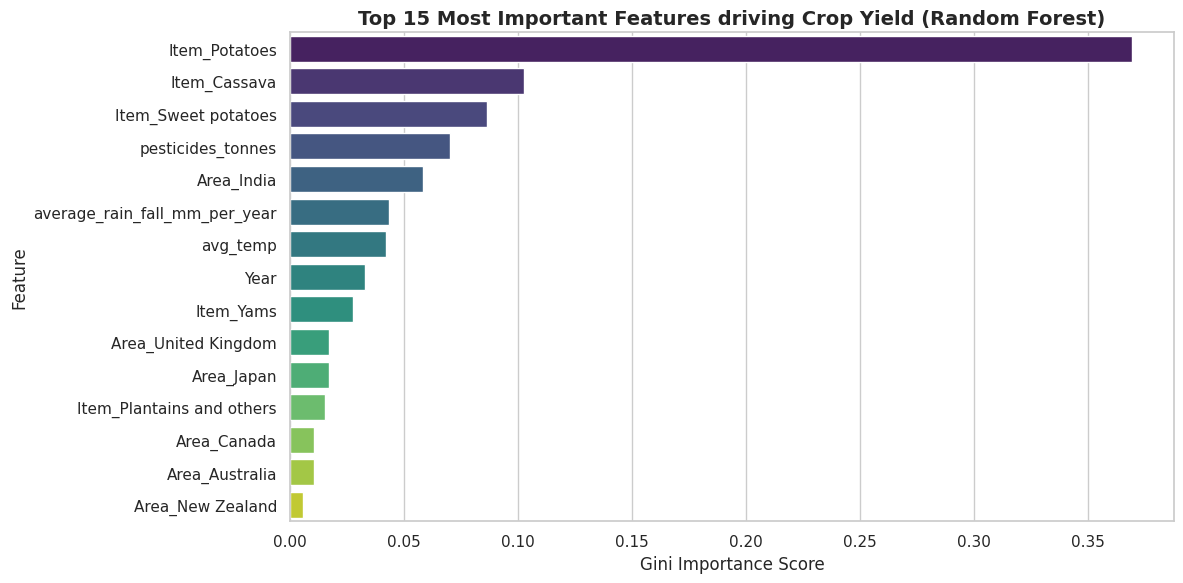

In [22]:
# ==========================================
# Phase 8: Feature Importance & SHAP Analysis
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Extract winning pipeline and components
winning_pipeline = trained_pipelines['Random Forest Regressor']
model_rf = winning_pipeline.named_steps['regressor']
preprocessor_rf = winning_pipeline.named_steps['preprocessor']

# Extract feature names after One-Hot Encoding
num_features = numerical_cols
cat_features = list(preprocessor_rf.named_transformers_['cat'].get_feature_names_out(categorical_cols))
all_feature_names = num_features + cat_features

# Get feature importances from Random Forest
importances = model_rf.feature_importances_
feature_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot Top 15 Most Important Features
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_imp_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features driving Crop Yield (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Gini Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Phase 8: Feature Importance Findings & Validation

#### 1. Crop Biological Dominance
* **`Item_Potatoes`** emerged as the most dominant feature, accounting for approximately **37% of Gini importance**, followed by **`Item_Cassava`** (~10%) and **`Item_Sweet potatoes`** (~8%).
* This validates our Phase 3 EDA hypothesis: tuber crops possess fundamentally different per-hectare yield baselines compared to grain crops.

#### 2. Environmental & Geographic Key Drivers
* **`pesticides_tonnes`** is the top numerical driver (~7%), followed by **`average_rain_fall_mm_per_year`** (~4%) and **`avg_temp`** (~4%).
* **`Area_India`** stands out as the most influential geographic feature (~6%), representing high agricultural volume variance in South Asia.

---

# Phase 9: Model Serialization & Production Artifact Export

### Objective
Serialize the fully trained `Pipeline` object (including `ColumnTransformer` preprocessing and `RandomForestRegressor`) into a `.pkl` file using `joblib` for deployment in the Streamlit web application.

In [23]:
# ==========================================
# Phase 9: Model Serialization (Export)
# ==========================================

import joblib
import os

# Define output file path (Google Drive)
export_path = '/content/drive/MyDrive/dataset/crop_yield_pipeline.pkl'

# Save the entire pipeline (Preprocessor + Model)
joblib.dump(winning_pipeline, export_path)

# Verify file size and existence
if os.path.exists(export_path):
    file_size_mb = os.path.getsize(export_path) / (1024 * 1024)
    print("=== MODEL SERIALIZATION SUCCESSFUL ===")
    print(f"Saved File Path: {export_path}")
    print(f"File Size: {file_size_mb:.2f} MB")
else:
    print("Error: Model serialization failed!")

=== MODEL SERIALIZATION SUCCESSFUL ===
Saved File Path: /content/drive/MyDrive/dataset/crop_yield_pipeline.pkl
File Size: 130.71 MB


In [24]:
joblib.dump(winning_pipeline, '/content/drive/MyDrive/dataset/crop_yield_pipeline.pkl', compress=3)

['/content/drive/MyDrive/dataset/crop_yield_pipeline.pkl']

In [26]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 67.1 MB/s eta 0:00:00


In [28]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# Page Configuration
st.set_page_config(
    page_title="Global Crop Yield Predictor",
    page_icon="🌾",
    layout="wide"
)

st.title("🌾 Global Crop Yield Prediction System")
st.write("Production-Grade Machine Learning Pipeline (Random Forest Regressor)")

# Load Pipeline
@st.cache_resource
def load_pipeline():
    return joblib.load('crop_yield_pipeline.pkl')

try:
    pipeline = load_pipeline()
    st.sidebar.success("Model Loaded Successfully! ✅")
except Exception as e:
    st.sidebar.error(f"Model File Not Found: {e}")

# User Inputs
col1, col2 = st.columns(2)

with col1:
    area = st.text_input("Country (Area):", value="Pakistan")
    item = st.selectbox("Crop Type (Item):", ['Potatoes', 'Maize', 'Wheat', 'Rice, paddy', 'Soybeans', 'Cassava', 'Sweet potatoes', 'Yams', 'Sorghum', 'Plantains and others'])
    year = st.slider("Year:", 1990, 2030, 2024)

with col2:
    rainfall = st.number_input("Average Rainfall (mm/year):", value=1149.0)
    pesticides = st.number_input("Pesticides Used (Tonnes):", value=37000.0)
    temp = st.number_input("Average Temp (°C):", value=20.5)

if st.button("🚀 Estimate Crop Yield"):
    input_data = pd.DataFrame({
        'Area': [area],
        'Item': [item],
        'Year': [year],
        'average_rain_fall_mm_per_year': [rainfall],
        'pesticides_tonnes': [pesticides],
        'avg_temp': [temp]
    })

    try:
        pred_tons = pipeline.predict(input_data)[0]
        st.success(f"Predicted Yield: **{pred_tons:.3f} Tons / Hectare** ({pred_tons * 10000:,.0f} hg/ha)")
    except Exception as e:
        st.error(f"Prediction Error: {e}")

Writing app.py


In [29]:
import joblib

# Re-export with compression level 3
joblib.dump(winning_pipeline, '/content/drive/MyDrive/dataset/crop_yield_pipeline.pkl', compress=3)
print("Compressed model saved successfully!")

Compressed model saved successfully!
